<a href="https://colab.research.google.com/github/SrivaniVadlamannati/customer_response_prediction/blob/main/notebooks/customer_response_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Upload Dataset

In [40]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign (1).csv


# Load Dataset

In [41]:
import pandas as pd
for fn in uploaded.keys():
    dataset_path = fn
df = pd.read_csv(dataset_path, sep="\t")

In [42]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


#Dataset Exploration

In [43]:
# Dataset Structure
df.shape
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [44]:
# Data Types and Missing Values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [45]:
# Summary Statistics
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


# Experimental Framework Definition

The impact of feature engineering and segmentation on prediction performance will be evaluated using:

1. Baseline Model (no feature engineering)
2. Feature Selection:
   - Mutual Information
   - Recursive Feature Elimination (RFE)
   - PCA
3. Clustering:
   - K-Means
   - Hierarchical Clustering
4. Models:
   - Logistic Regression
   - Random Forest
5. Evaluation:
   - Accuracy
   - Precision, Recall, F1
   - ROC-AUC

# Data Preprocessing

In [46]:
#Handling Missing Values
df["Income"] = df["Income"].fillna(df["Income"].median())

In [47]:
#Converting date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_Days"] = (pd.to_datetime("today") - df["Dt_Customer"]).dt.days

In [48]:
#Feature Engineering
df["Age"] = 2024 - df["Year_Birth"]

df["Total_Spending"] = df[
    ["MntWines","MntFruits","MntMeatProducts",
     "MntFishProducts","MntSweetProducts","MntGoldProds"]
].sum(axis=1)

In [49]:
#Dropping unnecessary Columns
df.drop(["ID"], axis=1, inplace=True)
df.drop("Dt_Customer", axis=1, inplace=True)

In [50]:
#Encoding categorical variables
df = pd.get_dummies(df, drop_first=True)

In [51]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#X_scaled = scaler.fit_transform(df)

#Exploratory Data Analysis

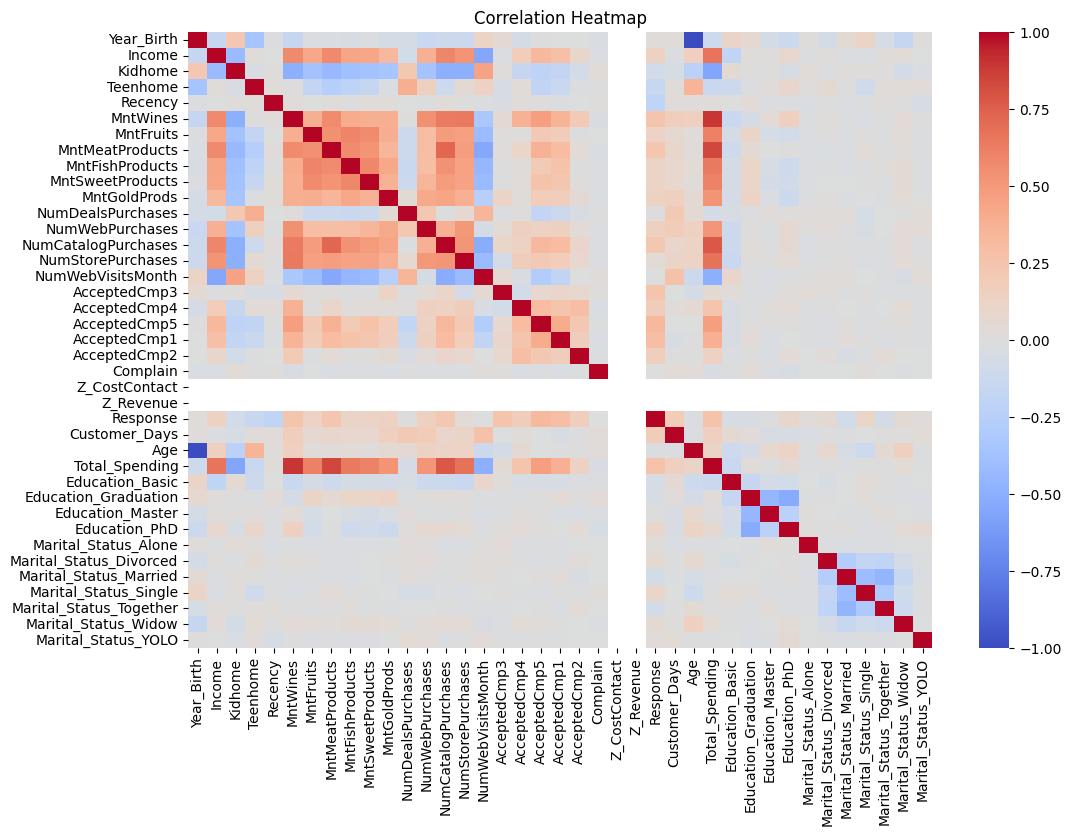

In [52]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

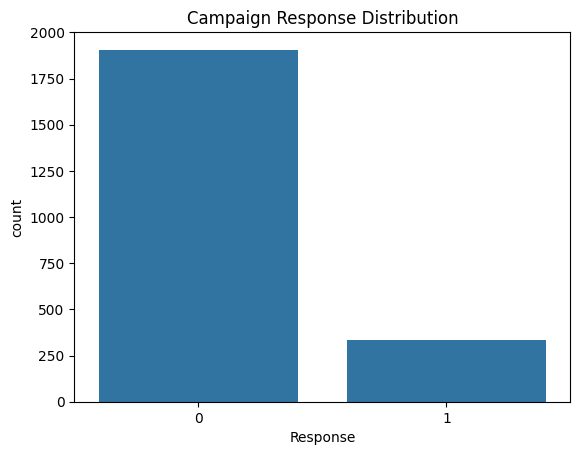

In [53]:
#Target Distribution
sns.countplot(x="Response", data=df)
plt.title("Campaign Response Distribution")
plt.show()

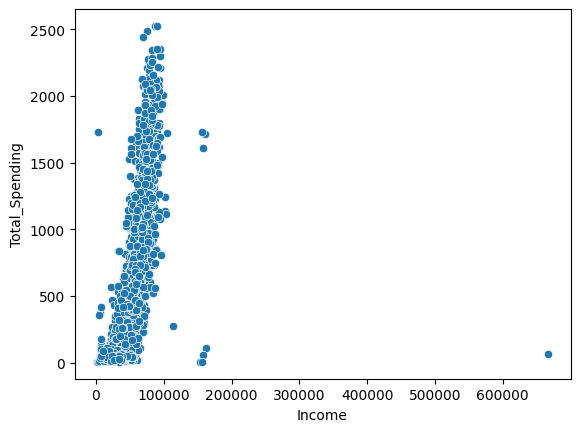

In [54]:
#Income vs Spending
sns.scatterplot(x="Income", y="Total_Spending", data=df)
plt.show()

#Baseline Model

In [55]:
#Defining Target
y = df["Response"]
X = df.drop("Response", axis=1)

In [56]:
#Splitting Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

#Metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       379
           1       0.64      0.33      0.44        69

    accuracy                           0.87       448
   macro avg       0.76      0.65      0.68       448
weighted avg       0.85      0.87      0.85       448



In [58]:
# Balanced Logistic Regression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model_bal = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced')
model_bal.fit(X_train_scaled, y_train)

# Predictions
y_pred_bal = model_bal.predict(X_test_scaled)
y_prob_bal = model_bal.predict_proba(X_test_scaled)[:,1]

# Metrics
print("Balanced Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Balanced F1:", f1_score(y_test, y_pred_bal))
print("Balanced AUC:", roc_auc_score(y_test, y_prob_bal))

Balanced Accuracy: 0.8214285714285714
Balanced F1: 0.5555555555555556
Balanced AUC: 0.8593552827807732


#Feature Selection

In [59]:
#Mutual Information
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Score": mi
}).sort_values(by="Score", ascending=False)

mi_df.head(10)

,Feature,Score
26,Total_Spending,0.048544
7,MntMeatProducts,0.042610
13,NumCatalogPurchases,0.038426
5,MntWines,0.037582
1,Income,0.037407
18,AcceptedCmp5,0.035546
10,MntGoldProds,0.025812
24,Customer_Days,0.025672
3,Teenhome,0.023292
14,NumStorePurchases,0.022768


In [60]:
# RFE
from sklearn.feature_selection import RFE

# Defining X and y
y = df["Response"]
X = df.drop("Response", axis=1)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# RFE with Logistic Regression
model = LogisticRegression(max_iter=2000, solver='liblinear')

rfe = RFE(model, n_features_to_select=15)
rfe.fit(X_train_scaled, y_train)

# Selected features
selected_features = X.columns[rfe.support_]

print("Selected Features:")
print(selected_features)

# Creating datasets with selected features
X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

Selected Features:
Index(['Teenhome', 'Recency', 'MntMeatProducts', 'NumWebPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'Customer_Days',
       'Education_Basic', 'Education_PhD', 'Marital_Status_Married',
       'Marital_Status_Together'],
      dtype='object')


In [61]:
#PCA
from sklearn.decomposition import PCA

# Initializing scaler
scaler = StandardScaler()

# Scaling original features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Applying PCA
pca = PCA(n_components=10)
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#Comparitive Experiments

In [62]:
#MI VS Baseline

model = LogisticRegression(max_iter=2000, solver='liblinear')
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred_base = model.predict(X_test_scaled)
y_prob_base = model.predict_proba(X_test_scaled)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_prob_base)

top_features = mi_df["Feature"].head(10).values

X_train_mi = X_train[top_features]
X_test_mi = X_test[top_features]

# Scaling MI features
X_train_mi_scaled = scaler.fit_transform(X_train_mi)
X_test_mi_scaled = scaler.transform(X_test_mi)

model.fit(X_train_mi_scaled, y_train)

y_pred_mi = model.predict(X_test_mi_scaled)
y_prob_mi = model.predict_proba(X_test_mi_scaled)[:, 1]

mi_acc = accuracy_score(y_test, y_pred_mi)
mi_f1 = f1_score(y_test, y_pred_mi)
mi_auc = roc_auc_score(y_test, y_prob_mi)

# Results
print("Baseline Accuracy:", baseline_acc)
print("Baseline F1:", baseline_f1)
print("Baseline AUC:", baseline_auc)

print("\nMI Accuracy:", mi_acc)
print("MI F1:", mi_f1)
print("MI AUC:", mi_auc)

Baseline Accuracy: 0.8683035714285714
Baseline F1: 0.4380952380952381
Baseline AUC: 0.854345914114183

MI Accuracy: 0.8504464285714286
MI F1: 0.24719101123595505
MI AUC: 0.7765286222324194


In [63]:
#RFE VS Baseline
# Baseline
model.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, model.predict(X_test))

# Scaling RFE features
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe)
X_test_rfe_scaled = scaler.transform(X_test_rfe)

model.fit(X_train_rfe_scaled, y_train)

# Predictions
y_pred_rfe = model.predict(X_test_rfe_scaled)
y_prob_rfe = model.predict_proba(X_test_rfe_scaled)[:, 1]

#Results
print("Baseline Accuracy:", baseline_acc)
print("RFE Accuracy:", accuracy_score(y_test, y_pred_rfe))
print("RFE F1:", f1_score(y_test, y_pred_rfe))
print("RFE AUC:", roc_auc_score(y_test, y_prob_rfe))

Baseline Accuracy: 0.859375
RFE Accuracy: 0.8660714285714286
RFE F1: 0.4117647058823529
RFE AUC: 0.853122251539138


In [64]:
#PCA VS Baseline
# Initialize model
model = LogisticRegression(max_iter=2000, solver='liblinear')

# Baseline
model.fit(X_train_scaled, y_train)

y_pred_base = model.predict(X_test_scaled)
y_prob_base = model.predict_proba(X_test_scaled)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_prob_base)

#PCA
model.fit(X_train_pca, y_train)

y_pred_pca = model.predict(X_test_pca)
y_prob_pca = model.predict_proba(X_test_pca)[:, 1]

pca_acc = accuracy_score(y_test, y_pred_pca)
pca_f1 = f1_score(y_test, y_pred_pca)
pca_auc = roc_auc_score(y_test, y_prob_pca)

#Results
print("Baseline Accuracy:", baseline_acc)
print("Baseline F1:", baseline_f1)
print("Baseline AUC:", baseline_auc)

print("\nPCA Accuracy:", pca_acc)
print("PCA F1:", pca_f1)
print("PCA AUC:", pca_auc)

Baseline Accuracy: 0.8683035714285714
Baseline F1: 0.4380952380952381
Baseline AUC: 0.854345914114183

PCA Accuracy: 0.8549107142857143
PCA F1: 0.38095238095238093
PCA AUC: 0.7710603801001874


# Clustering Implementation

In [65]:
# K-Means
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)

clusters_train = kmeans.fit_predict(X_train_scaled)
clusters_test = kmeans.predict(X_test_scaled)

# Adding to dataframe (optional for analysis)
df.loc[X_train.index, 'Cluster_KMeans'] = clusters_train
df.loc[X_test.index, 'Cluster_KMeans'] = clusters_test

In [66]:
# Hierarichal
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
clusters_train_hc = hc.fit_predict(X_train_scaled)
df.loc[X_train.index, 'Cluster_HC'] = clusters_train_hc

In [67]:
#check
df[['Cluster_KMeans','Cluster_HC']].head()

,Cluster_KMeans,Cluster_HC
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,1.0,0.0


#Segmentation Integration

In [68]:
#Adding cluster as feature to dataset
X_train_c = X_train.copy()
X_test_c = X_test.copy()

# Adding cluster labels
X_train_c['Cluster_KMeans'] = clusters_train
X_test_c['Cluster_KMeans'] = clusters_test

In [69]:
# SCALING + MODEL

scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Training model
model.fit(X_train_c_scaled, y_train)

y_pred = model.predict(X_test_c_scaled)
y_prob = model.predict_proba(X_test_c_scaled)[:,1]

print("With Clustering Accuracy:", accuracy_score(y_test, y_pred))
print("With Clustering F1:", f1_score(y_test, y_pred))
print("With Clustering AUC:", roc_auc_score(y_test, y_prob))

With Clustering Accuracy: 0.8638392857142857
With Clustering F1: 0.41904761904761906
With Clustering AUC: 0.8561431685212803
